# **Machine Learning Models for Binary Classification**

---

**Objective**: This notebook fits a logistic regression model, 1-hidden-layer fully connected NN, and 3-hidden-layer fully connected NN to the `Heart Disease` dataset at the UCI ML Repository.

---

### **S0. Data Import and Processing**

In [1]:
# Data preprocessing
import pandas as pd
import numpy as np
import random                                        # random number generation
from sklearn.preprocessing import StandardScaler, OneHotEncoder # standardization & one-hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split # training/test sets split

# Data visualization
import matplotlib.pyplot as plt

# Model evaluation
from sklearn.metrics import confusion_matrix         # confusion matrix
from sklearn.metrics import roc_curve, auc           # ROC curve and AUC
from sklearn.metrics import accuracy_score, log_loss # accuracy score and log-loss

In [ ]:
# Install the ucimlrepo package to access the 'Heart Disease' dataset
!pip install ucimlrepo

# Import function to fetch the dataset: Heart Disease at https://archive.ics.uci.edu/dataset/45/heart+disease
from ucimlrepo import fetch_ucirepo

In [3]:
# Fetch the dataset
heart_disease = fetch_ucirepo(name='Heart Disease')

In [4]:
# Display the variables and their types
variable_types = heart_disease.variables[['name', 'type']]
display(variable_types)

,name,type
0,age,Integer
1,sex,Categorical
2,cp,Categorical
3,trestbps,Integer
4,chol,Integer
5,fbs,Categorical
6,restecg,Categorical
7,thalach,Integer
8,exang,Categorical
9,oldpeak,Integer


In [5]:
# Create features and target (in pandas dataframes)
X_ini = heart_disease.data.features
y_ini = heart_disease.data.targets

# Display the first five rows of X_all and y_ini to verify
display(X_ini.head(), y_ini.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [8]:
# Check the dimension of X_ini and y_ini
print(f"Dimension of X_ini: {X_ini.shape}")
print(f"Dimension of y_ini: {y_ini.shape}")

Dimension of X_ini: (303, 13)
Dimension of y_ini: (303, 1)


In [17]:
# Drop 'ca' and 'thal' variables for simplicity in this notebook
X_raw = X_ini.drop(['ca', 'thal'], axis=1)

# Create a binary target y from y_ini
y = y_ini.apply(lambda x: 1 if x['num'] > 0 else 0, axis=1)
y.name = 'label'

In [18]:
# Specify each variable as either numerical or categorial variable
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']   # 'ca' dropped
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope'] # 'thal' dropped

print(f"Identified Numerical Features: {numerical_features}")
print(f"Identified Categorical Features: {categorical_features}")

Identified Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Identified Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']


In [19]:
# Create a column transformer for preprocessing to standardize numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # standardize to mean=0, std=1
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # one hot encode
    ],
    remainder='passthrough' # 'passthrough' will keep any columns not specified
)

In [20]:
# Apply the preprocessing to X_all
X_processed_array = preprocessor.fit_transform(X_raw)  # note: no meaningful column names

# Get feature names after transformation for creating a DataFrame
processed_feature_names = numerical_features.copy()    # Use numerical_features as defined for preprocessor

# Get one-hot encoded feature names
if categorical_features:
    onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    processed_feature_names.extend(onehot_feature_names)

# Convert the processed numpy array back to a Pandas DataFrame
X_processed = pd.DataFrame(X_processed_array, columns=processed_feature_names).astype(np.float32)

# Display the head of the new X_processed dataframe
display(X_processed.head())

,age,trestbps,chol,thalach,oldpeak,sex_0,sex_1,cp_1,cp_2,cp_3,...,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exang_0,exang_1,slope_1,slope_2,slope_3
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


In [21]:
# Determine the features to use
X_selected = X_processed[numerical_features]    # Use numerical features in this notebook

# Display the head of the X_selected dataframe
display(X_selected.head())

,age,trestbps,chol,thalach,oldpeak
0,0.948726,0.757525,-0.264900,0.017197,1.087338
1,1.392002,1.611220,0.760415,-1.821905,0.397182
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147
3,-1.932564,-0.096170,0.063974,1.637359,2.122573
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912


In [22]:
# Split the X_selected (features) and y (target) dataframes into training and testing sets using a 75/25 split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.25, random_state=123
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (227, 5)
y_train shape: (227,)
X_test shape: (76, 5)
y_test shape: (76,)


### **S1. Data Visualization**

In [27]:
# Create a dataframe for visualization
df_train = pd.concat([X_train, y_train], axis=1)

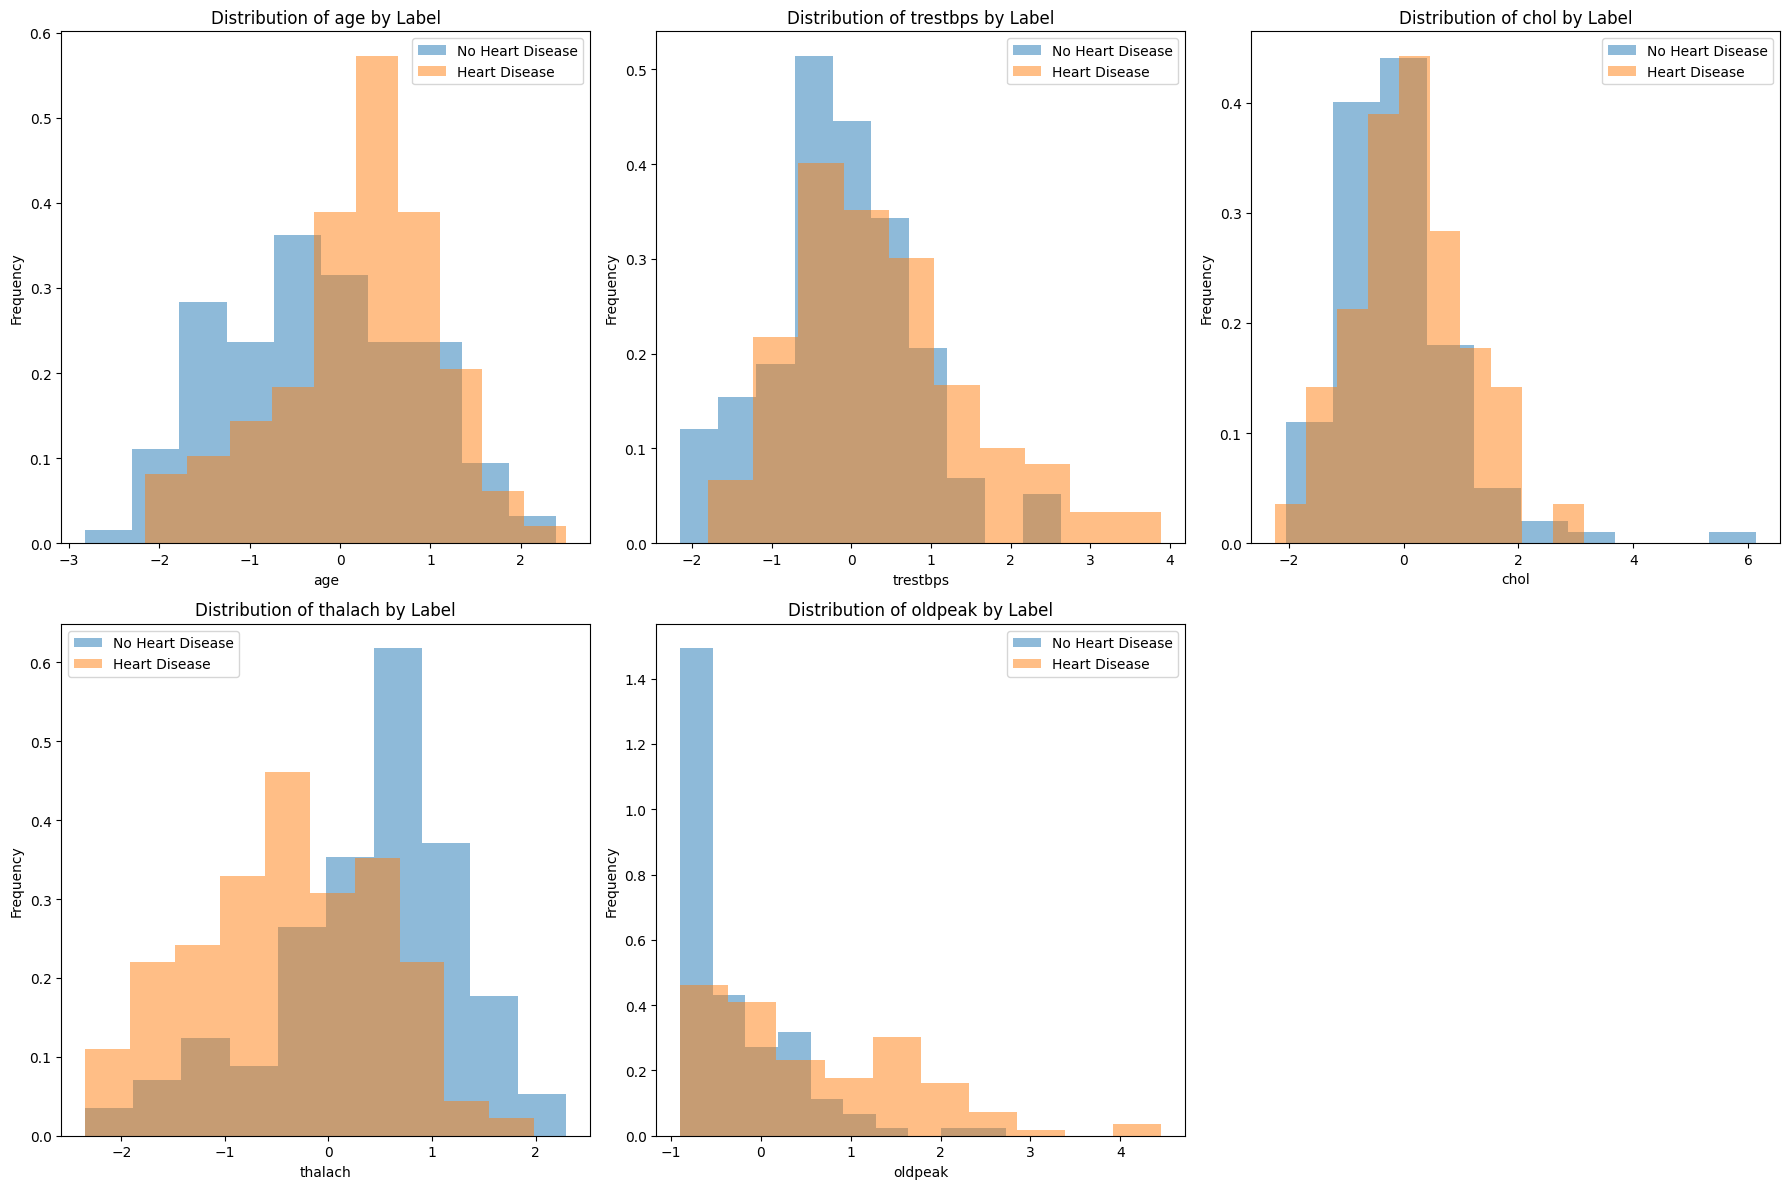

In [26]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()  # Flatten the 2x3 array of axes for easier iteration

# Plot the target label vs each numerical variable in subplots using histogram
for i, feature_name in enumerate(numerical_features):
  if i < len(axes):    # Ensure we don't go out of bounds if there are more features than subplots
    df_train.groupby("label")[feature_name].plot.hist(alpha=0.5, density=True, legend=True, ax=axes[i])
    axes[i].set_xlabel(feature_name)
    axes[i].set_title(f'Distribution of {feature_name} by Label')
    axes[i].legend(['No Heart Disease', 'Heart Disease'])

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()     # Adjust layout to prevent overlapping titles/labels
plt.show()

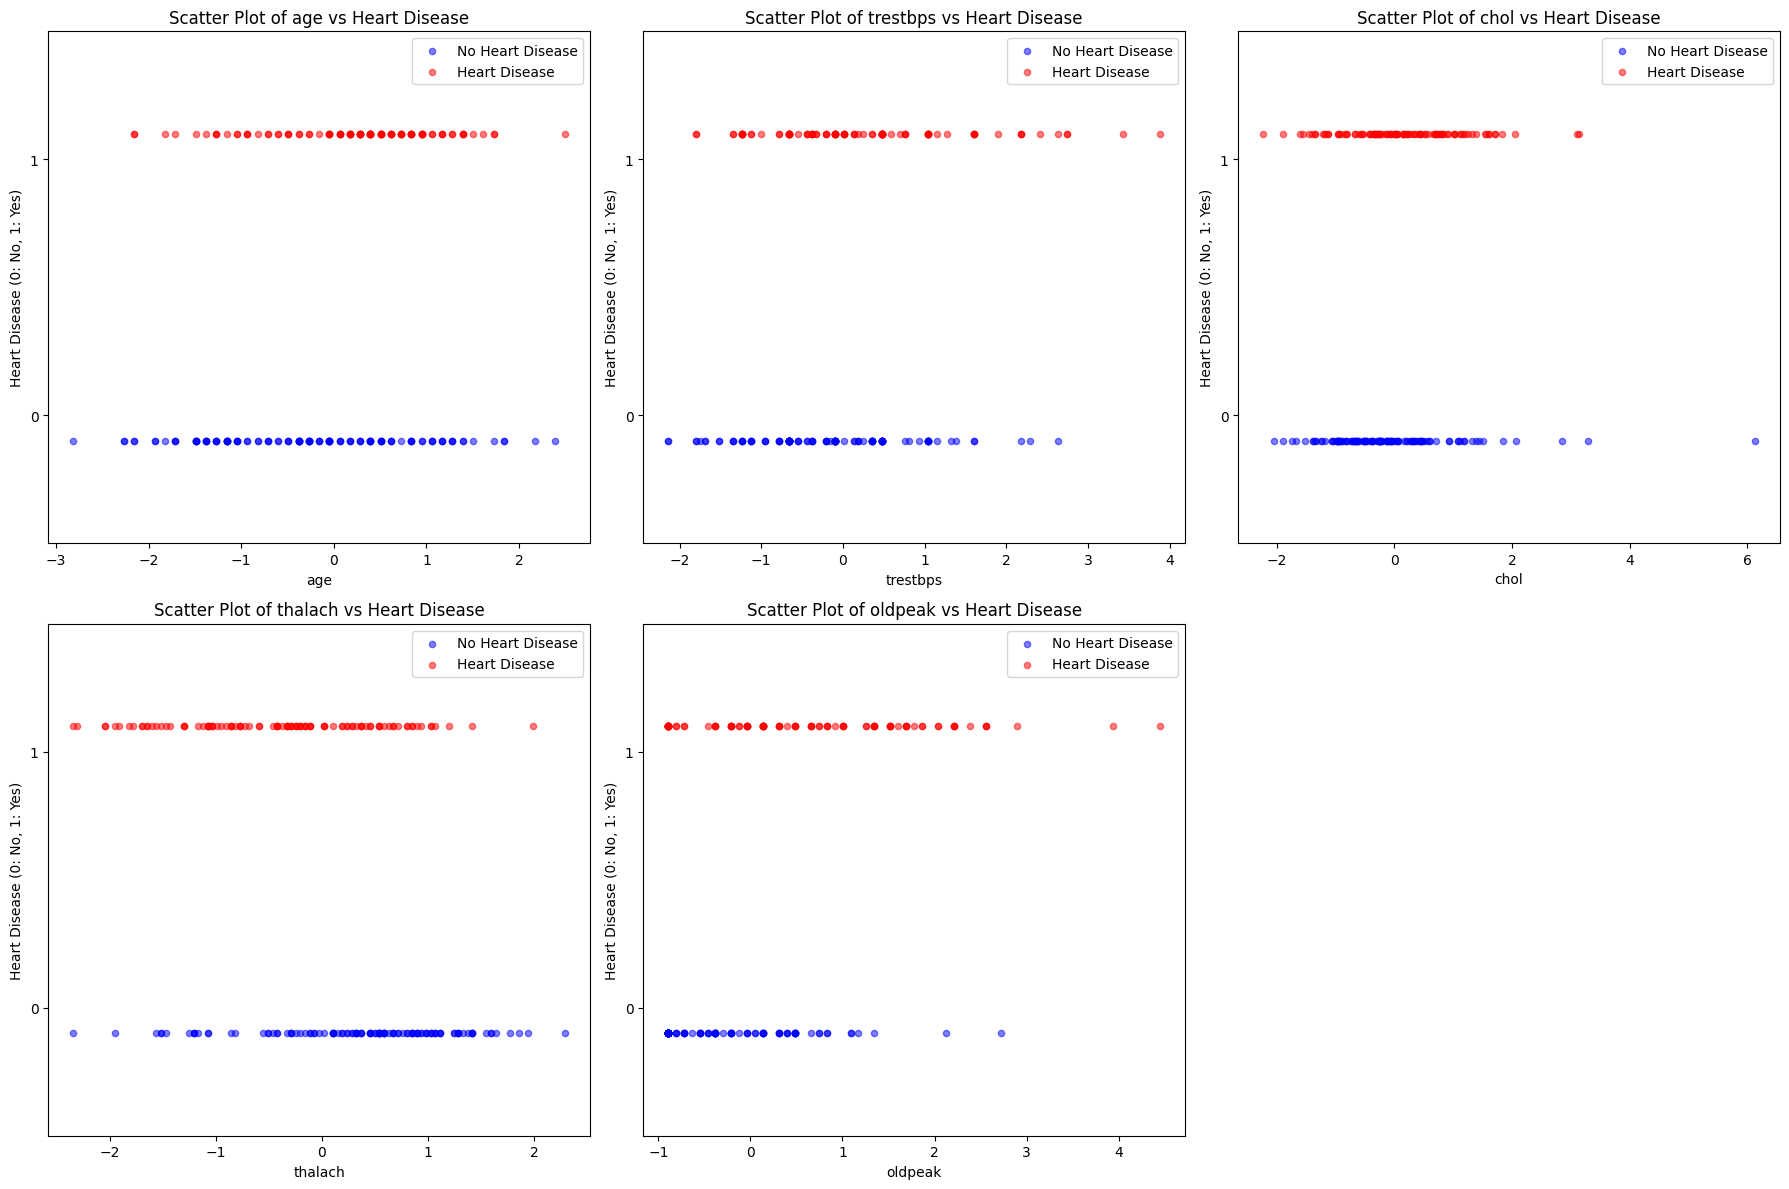

In [28]:
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()  # Flatten the 2x3 array of axes for easier iteration

# Plot the target label vs each numerical variable in subplots using scatter plot
for i, feature_name in enumerate(numerical_features):
  if i < len(axes):    # Ensure we don't go out of bounds if there are more features than subplots
    # Separate data for 'No Heart Disease' (label=0) and 'Heart Disease' (label=1)
    df_no_disease = df_train[df_train['label'] == 0]
    df_disease = df_train[df_train['label'] == 1]

    # Plot points for label 0 slightly below the 0 mark and label 1 slightly above the 1 mark
    axes[i].scatter(df_no_disease[feature_name], df_no_disease['label'] - 0.1, alpha=0.5, label='No Heart Disease', color='blue', s=20)
    axes[i].scatter(df_disease[feature_name], df_disease['label'] + 0.1, alpha=0.5, label='Heart Disease', color='red', s=20)

    axes[i].set_xlabel(feature_name)
    axes[i].set_ylabel("Heart Disease (0: No, 1: Yes)")
    axes[i].set_title(f'Scatter Plot of {feature_name} vs Heart Disease')
    axes[i].set_yticks([0, 1]) # Ensure binary ticks
    axes[i].set_ylim([-0.5, 1.5]) # Add some padding to y-axis limits
    axes[i].legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()     # Adjust layout to prevent overlapping titles/labels
plt.show()

### **S2. Logistic regression**

In [29]:
# Import the LogisticRegression function
from sklearn.linear_model import LogisticRegression

In [30]:
# Initialize the Logistic Regression model
model_LR = LogisticRegression()

# Train the model using the training data
model_LR.fit(X_train, y_train)

# Print the model parameters
print(f'Weights: {model_LR.coef_[0].round(4)}, Bias: {model_LR.intercept_[0]:.4f}')

Weights: [ 0.0149  0.2453  0.192  -0.701   0.799 ], Bias: -0.1822


In [35]:
# Estimate the probability of Y=1 on the training data
y_prob_LR_train = model_LR.predict_proba(X_train)[:, 1]

# Make predictions on the training data
y_pred_LR_train = model_LR.predict(X_train)

# Create a DataFrame with the actual and predicted values
df_pred_LR_train = pd.DataFrame({
    'y_obsv': y_train,
    'y_prob': y_prob_LR_train,
    'y_pred': y_pred_LR_train
})

# Display the first five rows of the predictions DataFrame
display(df_pred_LR_train.head())

,y_obsv,y_prob,y_pred
36,1,0.784538,1
148,0,0.203570,0
21,0,0.451782,0
187,1,0.603896,1
161,1,0.245542,0


In [36]:
# Estimate the probability of Y=1 on the test data
y_prob_LR_test = model_LR.predict_proba(X_test)[:, 1]

# Make predictions on the training data
y_pred_LR_test = model_LR.predict(X_test)

# Create a DataFrame with the actual and predicted values
df_pred_LR_test = pd.DataFrame({
    'y_obsv': y_test,
    'y_prob': y_prob_LR_test,
    'y_pred': y_pred_LR_test
})

# Display the first five rows of the predictions DataFrame
display(df_pred_LR_test.head())

,y_obsv,y_prob,y_pred
11,0,0.546737,1
292,1,0.675770,1
269,0,0.230995,0
268,1,0.155696,0
94,0,0.181521,0


In [37]:
# Compute the confusion matrix on the training data
conf_matrix_LR_train = confusion_matrix(y_true=y_train, y_pred=y_pred_LR_train)

# Calculate the prediction accuracy on the training data
accuracy_LR_train = accuracy_score(y_true=y_train, y_pred=y_pred_LR_train)

# Print the results
print("Confusion Matrix for Logistic Regression (Training Data):\n", conf_matrix_LR_train)
print(f"Logistic Regression Accuracy (Training Data): {accuracy_LR_train:.4f}")

Confusion Matrix for Logistic Regression (Training Data):
 [[98 24]
 [35 70]]
Logistic Regression Accuracy (Training Data): 0.7401


In [38]:
# Compute the confusion matrix on the test data
conf_matrix_LR_test = confusion_matrix(y_true=y_test, y_pred=y_pred_LR_test)

# Calculate the prediction accuracy on the test data
accuracy_LR_test = accuracy_score(y_true=y_test, y_pred=y_pred_LR_test)

# Print the results
print("Confusion Matrix for Logistic Regression (Test Data):\n", conf_matrix_LR_test)
print(f"Logistic Regression Accuracy (Test Data): {accuracy_LR_test:.4f}")

Confusion Matrix for Logistic Regression (Test Data):
 [[33  9]
 [15 19]]
Logistic Regression Accuracy (Test Data): 0.6842


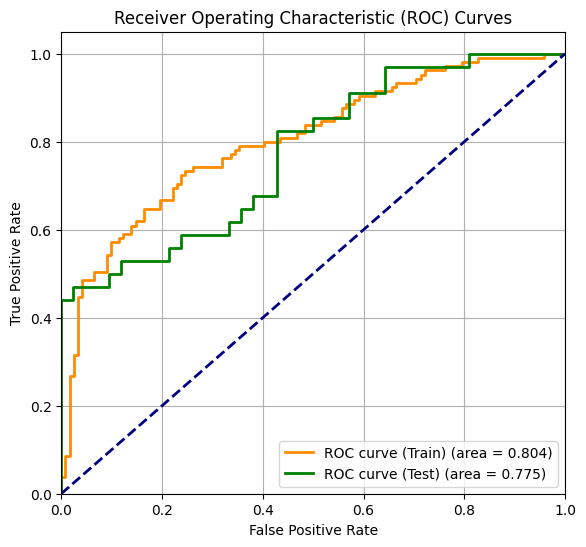

In [83]:
# Calculate ROC curve for training data
fpr_LR_train, tpr_LR_train, thr_LR_train = roc_curve(y_train, y_prob_LR_train)
roc_auc_LR_train = auc(fpr_LR_train, tpr_LR_train)

# Calculate ROC curve for test data
fpr_LR_test, tpr_LR_test, thr_LR_test = roc_curve(y_test, y_prob_LR_test)
roc_auc_LR_test = auc(fpr_LR_test, tpr_LR_test)

# Create a single plot to overlay both ROC curves
plt.figure(figsize=(6.5, 6))

plt.plot(fpr_LR_train, tpr_LR_train, color='darkorange', lw=2, label=f'ROC curve (Train) (area = {roc_auc_LR_train:.3f})')
plt.plot(fpr_LR_test, tpr_LR_test, color='green', lw=2, label=f'ROC curve (Test) (area = {roc_auc_LR_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **S3. Random Forest**

Following the pattern of the previous models, we will now implement a Random Forest Classifier. A Random Forest is an **ensemble learning method** that operates by constructing a multitude of decision trees during training. For classification tasks, the output of the Random Forest is the class selected by most trees (a process called *bagging* or *bootstrap aggregating*).

Each decision tree in the forest is built using a random subset of the training data and a random subset of features. A common criterion for splitting nodes in a decision tree is **Gini impurity**, which measures the probability of incorrectly classifying a randomly chosen element in the dataset if it were randomly labeled according to the class distribution in the dataset. For a node `t`, the Gini impurity is calculated as:

$$G(t) = 1 - \sum_{i=1}^{C} (p_i)^2$$

where $C$ is the number of classes and $p_i$ is the proportion of observations belonging to class $i$ at node `t`.

When making a prediction, each tree in the forest casts a 'vote' for a particular class. The final prediction of the Random Forest is then determined by **majority voting** among all the trees. For example, if we have $N$ trees and $N_c$ trees predict class $c$, the ensemble predicts class $c$ if $N_c > N / 2$.

Key characteristics of Random Forest:
*   **Ensemble Method**: It combines the predictions of several base estimators (decision trees) to improve overall accuracy and robustness over a single estimator.
*   **Randomness**: It introduces randomness in two ways:
    1.  **Bagging (Bootstrap Aggregating)**: Each tree is trained on a different random subset of the training data (sampled with replacement).
    2.  **Feature Randomness**: When splitting a node, each tree considers only a random subset of the features, rather than all features.
*   **Reduced Overfitting**: The randomness in feature selection and data sampling helps to prevent individual trees from overfitting to the training data, leading to better generalization on unseen data.
*   **High Accuracy**: Generally, Random Forests achieve high accuracy due to their ability to reduce variance.

This section will cover:

1.  **Model Initialization and Training**: Setting up and training the Random Forest model.
2.  **Prediction and Evaluation**: Calculating confusion matrices and accuracy for both training and test datasets.
3.  **ROC Curve Analysis**: Plotting and overlaying ROC curves for the training and test sets to visualize model performance.

In [40]:
# Import the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [41]:
# Initialize the Random Forest model using random_state for reproducibility
model_RF = RandomForestClassifier(random_state=12)

# Train the model using the training data
model_RF.fit(X_train, y_train)

RandomForestClassifier(random_state=12)

In [42]:
# --- Evaluation on Training Data ---
# Make predictions (probabilities) on the training data
y_prob_RF_train = model_RF.predict_proba(X_train)[:, 1]

# Make predictions (classes) on the training data
y_pred_RF_train = model_RF.predict(X_train)

# Compute the confusion matrix on the training data
conf_matrix_RF_train = confusion_matrix(y_true=y_train, y_pred=y_pred_RF_train)

# Calculate the prediction accuracy on the training data
accuracy_RF_train = accuracy_score(y_true=y_train, y_pred=y_pred_RF_train)

# Print the results for training data
print("Random Forest Model Training Results:")
print("Confusion Matrix (Training Data):\n", conf_matrix_RF_train)
print(f"Accuracy (Training Data): {accuracy_RF_train:.4f}")

Random Forest Model Training Results:
Confusion Matrix (Training Data):
 [[122   0]
 [  0 105]]
Accuracy (Training Data): 1.0000


In [43]:
# --- Evaluation on Test Data ---
# Make predictions (probabilities) on the test data
y_prob_RF_test = model_RF.predict_proba(X_test)[:, 1]

# Make predictions (classes) on the test data
y_pred_RF_test = model_RF.predict(X_test)

# Compute the confusion matrix on the test data
conf_matrix_RF_test = confusion_matrix(y_true=y_test, y_pred=y_pred_RF_test)

# Calculate the prediction accuracy on the test data
accuracy_RF_test = accuracy_score(y_true=y_test, y_pred=y_pred_RF_test)

# Print the results for test data
print("\nRandom Forest Model Test Results:")
print("Confusion Matrix (Test Data):\n", conf_matrix_RF_test)
print(f"Accuracy (Test Data): {accuracy_RF_test:.4f}")


Random Forest Model Test Results:
Confusion Matrix (Test Data):
 [[33  9]
 [12 22]]
Accuracy (Test Data): 0.7237


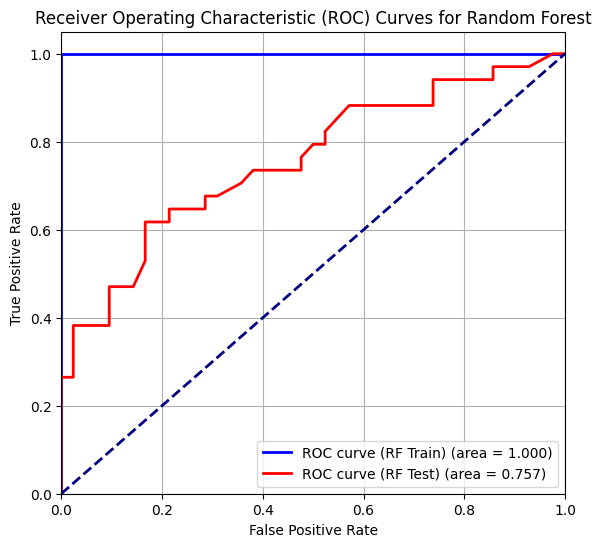

In [44]:
# --- Plotting ROC Curves ---
# Calculate ROC curve for training data
fpr_RF_train, tpr_RF_train, thr_RF_train = roc_curve(y_train, y_prob_RF_train)
roc_auc_RF_train = auc(fpr_RF_train, tpr_RF_train)

# Calculate ROC curve for test data
fpr_RF_test, tpr_RF_test, thr_RF_test = roc_curve(y_test, y_prob_RF_test)
roc_auc_RF_test = auc(fpr_RF_test, tpr_RF_test)

# Create a single plot to overlay both ROC curves
plt.figure(figsize=(6.5, 6))

plt.plot(fpr_RF_train, tpr_RF_train, color='blue', lw=2, label=f'ROC curve (RF Train) (area = {roc_auc_RF_train:.3f})')
plt.plot(fpr_RF_test, tpr_RF_test, color='red', lw=2, label=f'ROC curve (RF Test) (area = {roc_auc_RF_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Explanation for High Training Accuracy of Random Forest**

You'll notice that the Random Forest model achieved 100% accuracy on the **training data** (`accuracy_RF_train: 1.0000`). This is a common characteristic of Random Forest and other tree-based ensemble models, and it's important to understand why it happens and its implications.

**Why 100% Training Accuracy?**

1.  **Decision Tree Nature**: Individual decision trees are very powerful and can learn highly complex patterns. If allowed to grow indefinitely without pruning or regularization, a decision tree can memorize every data point in the training set, leading to 100% training accuracy. This is because a decision tree can create a unique path for every single observation.

2.  **Ensemble Power (Bagging)**: Random Forests build multiple decision trees on different bootstrap samples (random subsets with replacement) of the training data. Each tree tries to learn the training data as best as it can. With enough trees, and if the individual trees are deep enough, it's very likely that a significant portion of the training samples will be perfectly classified by at least some of the trees, and through majority voting, the ensemble can often achieve perfect or near-perfect classification on the data it was trained on.

3.  **Lack of Generalization**: While 100% training accuracy might seem ideal, it often indicates **overfitting**. Overfitting occurs when the model learns the training data, including its noise and outliers, too well. This leads to a model that performs exceptionally on the training set but poorly on unseen, new data (the test set). You can observe this phenomenon by comparing the training accuracy (100%) with the test accuracy (around 73.68%), which is significantly lower.

**How to Mitigate Overfitting in Random Forests?**

To prevent or reduce overfitting in Random Forests and improve their generalization ability, several hyperparameters can be tuned:

*   **`max_depth`**: Limits the maximum depth of each tree in the forest. A shallower tree is less likely to overfit.
*   **`min_samples_leaf`**: Specifies the minimum number of samples required to be at a leaf node. This prevents creating leaves that are too specific to a few training examples.
*   **`min_samples_split`**: The minimum number of samples required to split an internal node.
*   **`max_features`**: The number of features to consider when looking for the best split. Restricting this can introduce more randomness and reduce correlation between trees.
*   **`n_estimators`**: The number of trees in the forest. While more trees generally improve performance up to a point, it doesn't directly prevent overfitting of individual trees but stabilizes the ensemble's prediction.

By carefully tuning these parameters, we can find a balance between model complexity and generalization performance.

**Hyperparameter Tuning with Grid Search**

To address the overfitting observed with the default Random Forest model, we will perform a **Grid Search** to find optimal hyperparameters. This technique systematically works through multiple combinations of parameter values, cross-validating each combination to determine which yields the best performance on a validation set (or through cross-validation).

Key hyperparameters we will tune for Random Forest are:

*   `n_estimators`: The number of trees in the forest.
*   `max_features`: The number of features to consider when looking for the best split. Options include `sqrt` (square root of the number of features), `log2` (log base 2 of the number of features), or an integer/float.
*   `max_depth`: The maximum depth of the tree. Limiting this can reduce overfitting.
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least `min_samples_leaf` training samples in each of the left and right branches.

We will use `GridSearchCV` from `sklearn.model_selection` to automate this process.

In [45]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [47]:
# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],              # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],            # Number of features to consider at each split
    'max_depth': [4, 6, 8, None],                # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5, 10],             # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]                # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest model with a fixed random state for reproducibility
rf_model_base = RandomForestClassifier(random_state=12)

# Initialize GridSearchCV
#   estimator: The model to tune
#   param_grid: The dictionary of hyperparameters to search
#   cv: Number of folds for cross-validation (e.g., 5-fold cross-validation)
#   scoring: Metric to optimize (e.g., 'accuracy', 'roc_auc')
#   n_jobs: Number of jobs to run in parallel (-1 means use all available processors)
#   verbose: Controls the verbosity: the higher, the more messages.
grid_search = GridSearchCV(
    estimator=rf_model_base,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc', # 'accuracy' or 'roc_auc' are common choices
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
print("Starting Grid Search for Random Forest hyperparameters...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")

Starting Grid Search for Random Forest hyperparameters...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Grid Search complete.


In [48]:
# Print the best parameters and best score found by the grid search
print("Best parameters found: ", grid_search.best_params_)
print("Best ROC AUC score found: {:.4f}".format(grid_search.best_score_))

Best parameters found:  {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best ROC AUC score found: 0.7968


In [49]:
# Get the best estimator (model) from the grid search
model_RF_tuned = grid_search.best_estimator_

print("\nTuned Random Forest Model:\n", model_RF_tuned)


Tuned Random Forest Model:
 RandomForestClassifier(max_depth=6, min_samples_leaf=4, n_estimators=50,
                       random_state=12)


**Evaluation of Tuned Random Forest Model**

Now, we evaluate the performance of the Random Forest model with the hyperparameters tuned by `GridSearchCV`. We will check its accuracy and confusion matrix on both the training and test sets, and compare these results to the untuned model to see if overfitting has been reduced and generalization improved.

In [50]:
# --- Evaluation on Training Data for Tuned RF ---
# Make predictions (probabilities) on the training data
y_prob_RF_tuned_train = model_RF_tuned.predict_proba(X_train)[:, 1]

# Make predictions (classes) on the training data
y_pred_RF_tuned_train = model_RF_tuned.predict(X_train)

# Compute the confusion matrix on the training data
conf_matrix_RF_tuned_train = confusion_matrix(y_true=y_train, y_pred=y_pred_RF_tuned_train)

# Calculate the prediction accuracy on the training data
accuracy_RF_tuned_train = accuracy_score(y_true=y_train, y_pred=y_pred_RF_tuned_train)

# Print the results for training data
print("Tuned Random Forest Model Training Results:")
print("Confusion Matrix (Training Data):\n", conf_matrix_RF_tuned_train)
print(f"Accuracy (Training Data): {accuracy_RF_tuned_train:.4f}")

# --- Evaluation on Test Data for Tuned RF ---
# Make predictions (probabilities) on the test data
y_prob_RF_tuned_test = model_RF_tuned.predict_proba(X_test)[:, 1]

# Make predictions (classes) on the test data
y_pred_RF_tuned_test = model_RF_tuned.predict(X_test)

# Compute the confusion matrix on the test data
conf_matrix_RF_tuned_test = confusion_matrix(y_true=y_test, y_pred=y_pred_RF_tuned_test)

# Calculate the prediction accuracy on the test data
accuracy_RF_tuned_test = accuracy_score(y_true=y_test, y_pred=y_pred_RF_tuned_test)

# Print the results for test data
print("\nTuned Random Forest Model Test Results:")
print("Confusion Matrix (Test Data):\n", conf_matrix_RF_tuned_test)
print(f"Accuracy (Test Data): {accuracy_RF_tuned_test:.4f}")

Tuned Random Forest Model Training Results:
Confusion Matrix (Training Data):
 [[112  10]
 [ 21  84]]
Accuracy (Training Data): 0.8634

Tuned Random Forest Model Test Results:
Confusion Matrix (Test Data):
 [[31 11]
 [14 20]]
Accuracy (Test Data): 0.6711


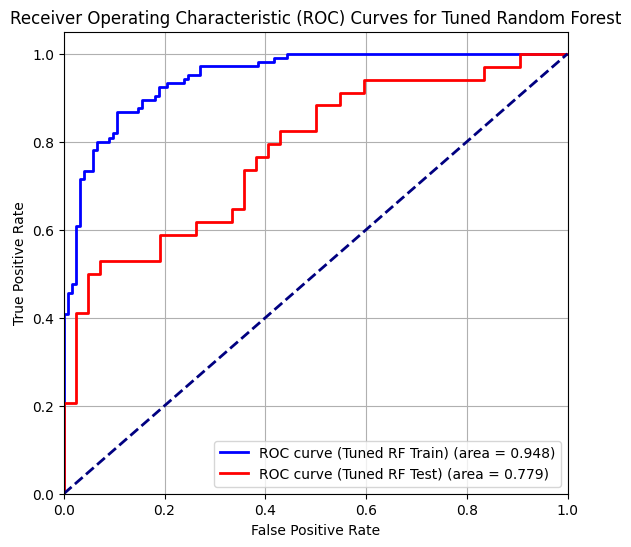

In [51]:
# --- Plotting ROC Curves for Tuned RF ---
# Calculate ROC curve for training data
fpr_RF_tuned_train, tpr_RF_tuned_train, _ = roc_curve(y_train, y_prob_RF_tuned_train)
roc_auc_RF_tuned_train = auc(fpr_RF_tuned_train, tpr_RF_tuned_train)

# Calculate ROC curve for test data
fpr_RF_tuned_test, tpr_RF_tuned_test, _ = roc_curve(y_test, y_prob_RF_tuned_test)
roc_auc_RF_tuned_test = auc(fpr_RF_tuned_test, tpr_RF_tuned_test)

# Create a single plot to overlay both ROC curves
plt.figure(figsize=(6.5, 6))

plt.plot(fpr_RF_tuned_train, tpr_RF_tuned_train, color='blue', lw=2, label=f'ROC curve (Tuned RF Train) (area = {roc_auc_RF_tuned_train:.3f})')
plt.plot(fpr_RF_tuned_test, tpr_RF_tuned_test, color='red', lw=2, label=f'ROC curve (Tuned RF Test) (area = {roc_auc_RF_tuned_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Tuned Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Comparison of ROC Curves: Tuned vs. Untuned Random Forest**

This plot overlays the ROC curves for both the untuned and tuned Random Forest models on their respective training and test sets. This allows for a direct visual comparison of how hyperparameter tuning impacted the model's performance and generalization ability. A well-tuned model should show a smaller gap between its training and test ROC curves, indicating reduced overfitting.

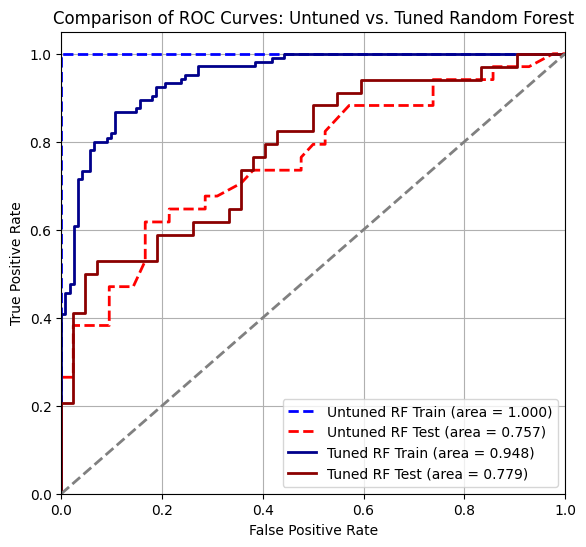

In [52]:
# Create a single plot to overlay all four ROC curves for comparison
plt.figure(figsize=(6.5, 6))

# Untuned Random Forest
plt.plot(fpr_RF_train, tpr_RF_train, color='blue', lw=2, linestyle='--', label=f'Untuned RF Train (area = {roc_auc_RF_train:.3f})')
plt.plot(fpr_RF_test, tpr_RF_test, color='red', lw=2, linestyle='--', label=f'Untuned RF Test (area = {roc_auc_RF_test:.3f})')

# Tuned Random Forest
plt.plot(fpr_RF_tuned_train, tpr_RF_tuned_train, color='darkblue', lw=2, label=f'Tuned RF Train (area = {roc_auc_RF_tuned_train:.3f})')
plt.plot(fpr_RF_tuned_test, tpr_RF_tuned_test, color='darkred', lw=2, label=f'Tuned RF Test (area = {roc_auc_RF_tuned_test:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison of ROC Curves: Untuned vs. Tuned Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **S4. A fully-connected NN with 1 hidden layer with 10 neurons**

In [53]:
# Import the torch packages for NN
import torch
import torch.nn as nn
import torch.optim as optim

In [54]:
# Prepare data (Convert to PyTorch Tensors)
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Note 1: .view(-1, 1) reshapes for BCEWithLogitsLoss
#        -1: "Infer the number of rows based on the data length"
#         1: "Force exactly 1 column"
# Note 2: all data must be floats to calculate gradients

In [65]:
# Define the Neural Network architecture
class NN_1HL(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NN_1HL, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()     # for binary classification

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)         # apply sigmoid for probabilities
        return out

In [72]:
# Instantiate the model, loss function, and optimizer
input_size = X_train_tensor.shape[1]  # number of features
hidden_size = 10
output_size = 1                       # binary classification

model_NN_1HL = NN_1HL(input_size, hidden_size, output_size)
criterion = nn.BCELoss()    # BCELoss = Binary Cross Entropy Loss, a standard for binary classification
optimizer = optim.SGD(model_NN_1HL.parameters(), lr=0.01)
# optimizer = optim.Adam(model_NN_1HL.parameters(), lr=0.01)

In [73]:
# Print the model to verify
print("NN_1HL Model Architecture:")
print(model_NN_1HL)
print("\nOptimizer:")
print(optimizer)

NN_1HL Model Architecture:
NN_1HL(
  (fc1): Linear(in_features=5, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Optimizer:
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [74]:
# Set a seed number to reproduce the results
seed_number = 314
torch.manual_seed(seed_number)
np.random.seed(seed_number)
random.seed(seed_number)

print(f"Random seeds set to {seed_number}")

Random seeds set to 314


In [75]:
# Print the random initial values of the weights and biases
with torch.no_grad():
    print("Initial Values:")
    print(f'\n fc1 Weights = \n {model_NN_1HL.fc1.weight.numpy().round(decimals=4)}, \
            \n fc1 Bias    = \n {model_NN_1HL.fc1.bias.numpy().round(decimals=4)}')
    print(f'\n fc2 Weights = \n {model_NN_1HL.fc2.weight.numpy().round(decimals=4)}, \
            \n fc2 Bias    =    {model_NN_1HL.fc2.bias.numpy().round(decimals=4)}')

Initial Values:

 fc1 Weights = 
 [[ 0.1964  0.1158  0.1491 -0.1445  0.315 ]
 [-0.1676  0.0005 -0.032  -0.4398 -0.0475]
 [ 0.2709  0.0458 -0.1292 -0.1154  0.1637]
 [-0.1722 -0.0792  0.1004  0.2269 -0.0685]
 [-0.2753 -0.2168  0.4043 -0.0489 -0.173 ]
 [ 0.3555  0.2839  0.1966 -0.3928 -0.3067]
 [-0.2559 -0.4195  0.3559 -0.085  -0.3792]
 [ 0.0222  0.179  -0.1836  0.2642 -0.1546]
 [-0.1211 -0.3943  0.3682  0.3082 -0.1204]
 [-0.2609 -0.3066 -0.3792 -0.3923 -0.2765]],             
 fc1 Bias    = 
 [ 0.3052  0.3294 -0.0581 -0.1524  0.1878  0.2176 -0.3791  0.3821 -0.0318
 -0.2586]

 fc2 Weights = 
 [[ 0.1909 -0.1011  0.2233 -0.2573  0.2828  0.2411 -0.309  -0.0482  0.2106
  -0.2316]],             
 fc2 Bias    =    [-0.1299]


In [76]:
# Train the NN
num_epochs = 10_000

loss_history = []             # Initialize a list to store loss values
accuracy_history = []         # Initialize a list to store accuracy values

print('Starting training NN_1HL with Gradient Descent...')

for epoch in range(num_epochs):
    # Forward pass X_train_torch at once to the model and calculate predictions
    y_prob_1HL = model_NN_1HL(X_train_tensor)       # Predicted probability of y=1

    # Calculate the loss (all PyTorch syntax calls this loss)
    loss = criterion(y_prob_1HL, y_train_tensor)
    loss_history.append(loss.item())                # Append loss to history

    # Calculate the prediction accuracy
    y_pred_1HL = (y_prob_1HL > 0.5).float()
    accuracy = (y_pred_1HL == y_train_tensor).float().mean()
    accuracy_history.append(accuracy.item())        # Append accuracy to history

    # Backward and optimize
    optimizer.zero_grad()     # [1] Delete any previous gradient calculations
    loss.backward()           # [2] Do backpropagation
    optimizer.step()          # [3] Update the model parameters

    if (epoch + 1) % 100 == 0:
        # The lines below prevent Torch from remembering all
        # Otherwise, everything will be slower with larger datasets
        with torch.no_grad():
            print(f'Epoch [{epoch+1}/{num_epochs}] Loss = {loss.item():.5f}, Accuracy = {accuracy.item():.4f}')

print('Training complete!')

Starting training NN_1HL with Gradient Descent...
Epoch [100/10000] Loss = 0.63603, Accuracy = 0.7313
Epoch [200/10000] Loss = 0.61344, Accuracy = 0.7401
Epoch [300/10000] Loss = 0.59523, Accuracy = 0.7401
Epoch [400/10000] Loss = 0.58039, Accuracy = 0.7401
Epoch [500/10000] Loss = 0.56848, Accuracy = 0.7445
Epoch [600/10000] Loss = 0.55916, Accuracy = 0.7489
Epoch [700/10000] Loss = 0.55179, Accuracy = 0.7489
Epoch [800/10000] Loss = 0.54604, Accuracy = 0.7445
Epoch [900/10000] Loss = 0.54140, Accuracy = 0.7489
Epoch [1000/10000] Loss = 0.53767, Accuracy = 0.7533
Epoch [1100/10000] Loss = 0.53472, Accuracy = 0.7533
Epoch [1200/10000] Loss = 0.53240, Accuracy = 0.7577
Epoch [1300/10000] Loss = 0.53032, Accuracy = 0.7533
Epoch [1400/10000] Loss = 0.52838, Accuracy = 0.7533
Epoch [1500/10000] Loss = 0.52647, Accuracy = 0.7533
Epoch [1600/10000] Loss = 0.52466, Accuracy = 0.7533
Epoch [1700/10000] Loss = 0.52305, Accuracy = 0.7489
Epoch [1800/10000] Loss = 0.52146, Accuracy = 0.7489
Epoch

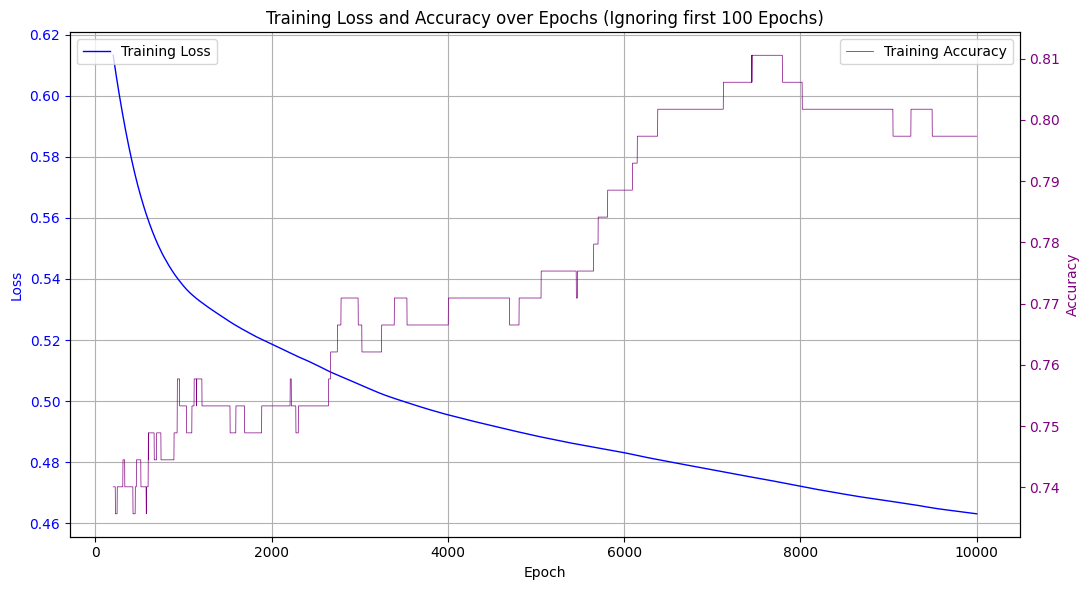

In [77]:
# Plot the loss and accuracy values against the epochs, ignoring the first 200 epochs
fig, ax1 = plt.subplots(figsize=(11, 6))

# Plot Loss on the first y-axis
ax1.plot(range(201, num_epochs + 1), loss_history[200:], color='blue', linestyle='-', label='Training Loss', linewidth=1)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params('y', colors='blue')
ax1.set_title('Training Loss and Accuracy over Epochs (Ignoring first 100 Epochs)')
ax1.grid(True)

# Create a second y-axis for Accuracy
ax2 = ax1.twinx()
ax2.plot(range(201, num_epochs + 1), accuracy_history[200:], color='purple', linestyle='-', label='Training Accuracy', linewidth=0.5)
ax2.set_ylabel('Accuracy', color='purple')
ax2.tick_params('y', colors='purple')

# Add legends from both axes
fig.tight_layout() # otherwise the right y-label is slightly clipped
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [78]:
# Print the final learned values of the weights and bias
with torch.no_grad():
   print("Final Trained Values:")
   print(f'\n fc1 Weights = \n {model_NN_1HL.fc1.weight.numpy().round(decimals=4)}, \
           \n fc1 Bias    = \n {model_NN_1HL.fc1.bias.numpy().round(decimals=4)}')
   print(f'\n fc2 Weights = \n {model_NN_1HL.fc2.weight.numpy().round(decimals=4)}, \
           \n fc2 Bias    =    {model_NN_1HL.fc2.bias.numpy().round(decimals=4)}')

Final Trained Values:

 fc1 Weights = 
 [[-0.5394  0.6881  0.1101 -0.5118  0.5016]
 [-0.496  -0.0384  0.1119 -0.6046 -0.0187]
 [ 0.011  -0.5273 -0.0308 -0.1693  0.7395]
 [-0.6024 -0.1405  0.1385  0.5108  0.0009]
 [-0.0611 -0.3797  0.3872  0.0223  0.1869]
 [ 0.0779  0.4845  0.3401 -0.2264 -0.3782]
 [-0.4291 -0.3466  0.7855  0.0366 -0.3759]
 [-0.2798  0.5591 -0.2399  0.5182  0.1847]
 [-0.0309 -0.4701  0.3291  0.3068 -0.1543]
 [ 0.1988 -0.434  -0.3455 -0.586  -0.7429]],            
 fc1 Bias    = 
 [ 0.3695  0.2304 -0.0942  0.2812  0.352   0.0613 -0.287   0.3694 -0.003
 -0.1644]

 fc2 Weights = 
 [[ 1.0842  0.5966  0.8818 -0.8262  0.428   0.2668 -0.7608 -0.7642  0.2763
  -0.8486]],            
 fc2 Bias    =    [-0.2669]


In [79]:
# Evaluate the model on the training data
with torch.no_grad():
    y_prob_NN_train = model_NN_1HL(X_train_tensor)
    y_pred_NN_train = (y_prob_NN_train > 0.5).float()

    # Convert tensors to numpy arrays for sklearn metrics
    y_train_np = y_train_tensor.cpu().numpy()
    y_pred_NN_train_np = y_pred_NN_train.cpu().numpy()

    # Compute the confusion matrix on the training data
    conf_matrix_NN_train = confusion_matrix(y_true=y_train_np, y_pred=y_pred_NN_train_np)

    # Calculate the prediction accuracy on the training data
    accuracy_NN_train = accuracy_score(y_true=y_train_np, y_pred=y_pred_NN_train_np)

    # Print the results
    print("Confusion Matrix for NN (Training Data):\n", conf_matrix_NN_train)
    print(f"NN Accuracy (Training Data): {accuracy_NN_train:.4f}")

Confusion Matrix for NN (Training Data):
 [[106  16]
 [ 30  75]]
NN Accuracy (Training Data): 0.7974


In [80]:
# Evaluate the model on the test data
with torch.no_grad():
    y_prob_NN_test = model_NN_1HL(X_test_tensor)
    y_pred_NN_test = (y_prob_NN_test > 0.5).float()

    # Convert tensors to numpy arrays for sklearn metrics
    y_test_np = y_test_tensor.cpu().numpy()
    y_pred_NN_test_np = y_pred_NN_test.cpu().numpy()

    # Compute the confusion matrix on the test data
    conf_matrix_NN_test = confusion_matrix(y_true=y_test_np, y_pred=y_pred_NN_test_np)

    # Calculate the prediction accuracy on the test data
    accuracy_NN_test = accuracy_score(y_true=y_test_np, y_pred=y_pred_NN_test_np)

    # Print the results
    print("Confusion Matrix for NN (Test Data):\n", conf_matrix_NN_test)
    print(f"NN Accuracy (Test Data): {accuracy_NN_test:.4f}")

Confusion Matrix for NN (Test Data):
 [[32 10]
 [14 20]]
NN Accuracy (Test Data): 0.6842


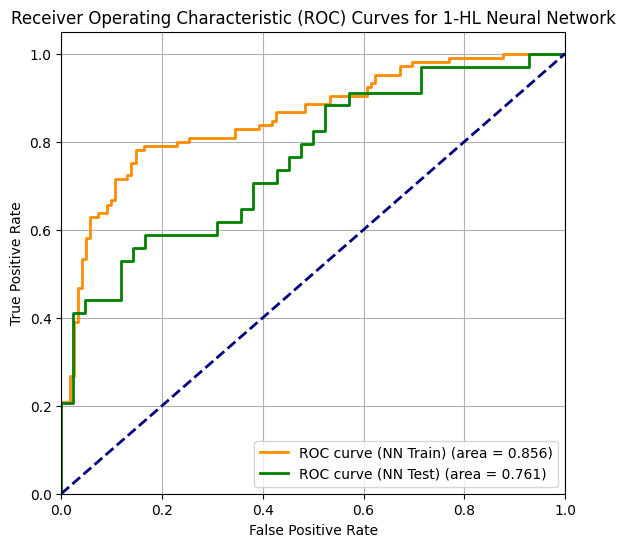

In [84]:
# Calculate ROC curve for training data (Neural Network)
with torch.no_grad():
    y_prob_NN_train = model_NN_1HL(X_train_tensor)
    fpr_NN_train, tpr_NN_train, thr_NN_train = roc_curve(y_train_tensor.cpu().numpy(), y_prob_NN_train.cpu().numpy())
    roc_auc_NN_train = auc(fpr_NN_train, tpr_NN_train)

# Calculate ROC curve for test data (Neural Network)
with torch.no_grad():
    y_prob_NN_test = model_NN_1HL(X_test_tensor)
    fpr_NN_test, tpr_NN_test, thr_NN_test = roc_curve(y_test_tensor.cpu().numpy(), y_prob_NN_test.cpu().numpy())
    roc_auc_NN_test = auc(fpr_NN_test, tpr_NN_test)

# Create a single plot to overlay both ROC curves for the Neural Network
plt.figure(figsize=(6.5, 6))

plt.plot(fpr_NN_train, tpr_NN_train, color='darkorange', lw=2, label=f'ROC curve (NN Train) (area = {roc_auc_NN_train:.3f})')
plt.plot(fpr_NN_test, tpr_NN_test, color='green', lw=2, label=f'ROC curve (NN Test) (area = {roc_auc_NN_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for 1-HL Neural Network')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **S5. A fully-connected NN with 3 hidden layers**

In [85]:
# Define the Neural Network architecture with 3 hidden layers
class NN_3HL(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
        super(NN_3HL, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(hidden_size3, output_size)
        self.sigmoid = nn.Sigmoid() # for binary classification

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        out = self.relu3(out)
        out = self.fc4(out)
        out = self.sigmoid(out)    # apply sigmoid for probabilities
        return out

In [86]:
# Instantiate the 3-hidden layer Model, Loss Function, and Optimizer
input_size = X_train_tensor.shape[1] # number of features
hidden_size1 = 10
hidden_size2 = 8
hidden_size3 = 4
output_size = 1                      # binary classification

model_NN_3HL = NN_3HL(input_size, hidden_size1, hidden_size2, hidden_size3, output_size)
criterion_3HL = nn.BCELoss()         # BCELoss = Binary Cross Entropy Loss
optimizer_3HL = optim.SGD(model_NN_3HL.parameters(), lr=0.01)

# Print the model to verify
print("NN_3HL Model Architecture:")
print(model_NN_3HL)
print("\nOptimizer:")
print(optimizer_3HL)

NN_3HL Model Architecture:
NN_3HL(
  (fc1): Linear(in_features=5, out_features=10, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=10, out_features=8, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=8, out_features=4, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Optimizer:
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [87]:
# Set a seed number to reproduce the results for the 3-hidden layer NN
seed_number_3HL = 314     # Use a different seed for distinct results
torch.manual_seed(seed_number_3HL)
np.random.seed(seed_number_3HL)
random.seed(seed_number_3HL)

print(f"Random seeds for 3-HL NN set to {seed_number_3HL}")

Random seeds for 3-HL NN set to 314


In [88]:
# Print the random initial values of the weights and biases for the 3-hidden layer NN
with torch.no_grad():
    print("Initial Values (NN_3HL):")
    print(f'\n fc1 Weights = \n {model_NN_3HL.fc1.weight.numpy().round(decimals=4)}, \
            \n fc1 Bias    = \n {model_NN_3HL.fc1.bias.numpy().round(decimals=4)}')
    print(f'\n fc2 Weights = \n {model_NN_3HL.fc2.weight.numpy().round(decimals=4)}, \
            \n fc2 Bias    = \n {model_NN_3HL.fc2.bias.numpy().round(decimals=4)}')
    print(f'\n fc3 Weights = \n {model_NN_3HL.fc3.weight.numpy().round(decimals=4)}, \
            \n fc3 Bias    = \n {model_NN_3HL.fc3.bias.numpy().round(decimals=4)}')
    print(f'\n fc4 Weights = \n {model_NN_3HL.fc4.weight.numpy().round(decimals=4)}, \
            \n fc4 Bias    =    {model_NN_3HL.fc4.bias.numpy().round(decimals=4)}')


Initial Values (NN_3HL):

 fc1 Weights = 
 [[ 0.1964  0.1158  0.1491 -0.1445  0.315 ]
 [-0.1676  0.0005 -0.032  -0.4398 -0.0475]
 [ 0.2709  0.0458 -0.1292 -0.1154  0.1637]
 [-0.1722 -0.0792  0.1004  0.2269 -0.0685]
 [-0.2753 -0.2168  0.4043 -0.0489 -0.173 ]
 [ 0.3555  0.2839  0.1966 -0.3928 -0.3067]
 [-0.2559 -0.4195  0.3559 -0.085  -0.3792]
 [ 0.0222  0.179  -0.1836  0.2642 -0.1546]
 [-0.1211 -0.3943  0.3682  0.3082 -0.1204]
 [-0.2609 -0.3066 -0.3792 -0.3923 -0.2765]],             
 fc1 Bias    = 
 [ 0.3052  0.3294 -0.0581 -0.1524  0.1878  0.2176 -0.3791  0.3821 -0.0318
 -0.2586]

 fc2 Weights = 
 [[ 0.1909 -0.1011  0.2233 -0.2573  0.2828  0.2411 -0.309  -0.0482  0.2106
  -0.2316]
 [-0.1299  0.2988  0.2568 -0.2782 -0.2945  0.0327  0.2737 -0.0961 -0.2018
  -0.1884]
 [ 0.0187  0.0329  0.1698 -0.3101  0.0662  0.3055  0.1437  0.0413  0.3115
  -0.267 ]
 [-0.014   0.0542 -0.1249 -0.153   0.0583  0.247   0.1279  0.169   0.1697
   0.2879]
 [-0.0425 -0.3155  0.2277 -0.2355 -0.1769 -0.0655 -0.2

In [89]:
# Train the 3-hidden layer NN
num_epochs = 10_000

loss_history_3HL = []             # Initialize a list to store loss values
accuracy_history_3HL = []         # Initialize a list to store accuracy values

print('Starting training NN_3HL with Gradient Descent...')

for epoch in range(num_epochs):
    # Forward pass X_train_torch at once to the model and calculate predictions
    y_prob_3HL = model_NN_3HL(X_train_tensor)       # Predicted probability of y=1

    # Calculate the loss
    loss_3HL = criterion_3HL(y_prob_3HL, y_train_tensor)
    loss_history_3HL.append(loss_3HL.item())                # Append loss to history

    # Calculate the prediction accuracy
    y_pred_3HL = (y_prob_3HL > 0.5).float()
    accuracy_3HL = (y_pred_3HL == y_train_tensor).float().mean()
    accuracy_history_3HL.append(accuracy_3HL.item())        # Append accuracy to history

    # Backward and optimize
    optimizer_3HL.zero_grad()     # [1] Delete any previous gradient calculations
    loss_3HL.backward()           # [2] Do backpropagation
    optimizer_3HL.step()          # [3] Update the model parameters

    if (epoch + 1) % 100 == 0:
        with torch.no_grad():
            print(f'Epoch [{epoch+1}/{num_epochs}] Loss = {loss_3HL.item():.5f}, Accuracy = {accuracy_3HL.item():.4f}')

print('NN_3HL Training complete!')

Starting training NN_3HL with Gradient Descent...
Epoch [100/10000] Loss = 0.68620, Accuracy = 0.5374
Epoch [200/10000] Loss = 0.68371, Accuracy = 0.5374
Epoch [300/10000] Loss = 0.68067, Accuracy = 0.5374
Epoch [400/10000] Loss = 0.67688, Accuracy = 0.5374
Epoch [500/10000] Loss = 0.67204, Accuracy = 0.5463
Epoch [600/10000] Loss = 0.66603, Accuracy = 0.5859
Epoch [700/10000] Loss = 0.65877, Accuracy = 0.6079
Epoch [800/10000] Loss = 0.64967, Accuracy = 0.6608
Epoch [900/10000] Loss = 0.63861, Accuracy = 0.6872
Epoch [1000/10000] Loss = 0.62585, Accuracy = 0.7048
Epoch [1100/10000] Loss = 0.61183, Accuracy = 0.7225
Epoch [1200/10000] Loss = 0.59698, Accuracy = 0.7313
Epoch [1300/10000] Loss = 0.58264, Accuracy = 0.7445
Epoch [1400/10000] Loss = 0.56998, Accuracy = 0.7269
Epoch [1500/10000] Loss = 0.55928, Accuracy = 0.7445
Epoch [1600/10000] Loss = 0.55051, Accuracy = 0.7445
Epoch [1700/10000] Loss = 0.54355, Accuracy = 0.7489
Epoch [1800/10000] Loss = 0.53804, Accuracy = 0.7489
Epoch

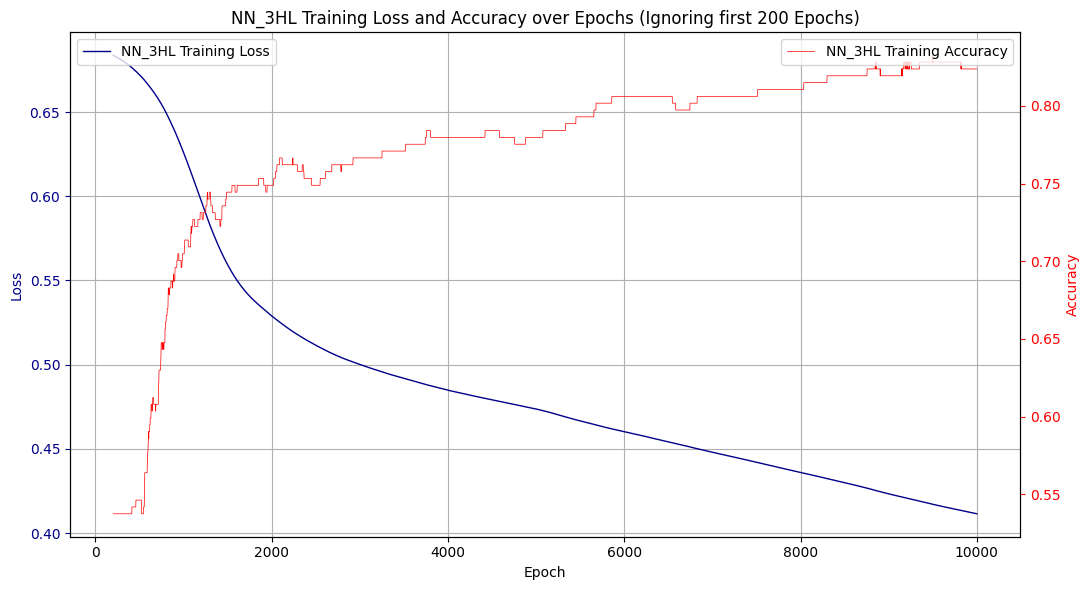

In [90]:
# Plot the loss and accuracy values for NN_3HL, ignoring the first 200 epochs
fig, ax1 = plt.subplots(figsize=(11, 6))

# Plot Loss on the first y-axis
ax1.plot(range(201, num_epochs + 1), loss_history_3HL[200:], color='darkblue', linestyle='-', label='NN_3HL Training Loss', linewidth=1)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='darkblue')
ax1.tick_params('y', colors='darkblue')
ax1.set_title('NN_3HL Training Loss and Accuracy over Epochs (Ignoring first 200 Epochs)')
ax1.grid(True)

# Create a second y-axis for Accuracy
ax2 = ax1.twinx()
ax2.plot(range(201, num_epochs + 1), accuracy_history_3HL[200:], color='red', linestyle='-', label='NN_3HL Training Accuracy', linewidth=0.5)
ax2.set_ylabel('Accuracy', color='red')
ax2.tick_params('y', colors='red')

# Add legends from both axes
fig.tight_layout() # otherwise the right y-label is slightly clipped
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [91]:
# Print the final learned values of the weights and bias for NN_3HL
with torch.no_grad():
   print("Final Trained Values (NN_3HL):")
   print(f'\n fc1 Weights = \n {model_NN_3HL.fc1.weight.numpy().round(decimals=4)}, \
           \n fc1 Bias    = \n {model_NN_3HL.fc1.bias.numpy().round(decimals=4)}')
   print(f'\n fc2 Weights = \n {model_NN_3HL.fc2.weight.numpy().round(decimals=4)}, \
           \n fc2 Bias    = \n {model_NN_3HL.fc2.bias.numpy().round(decimals=4)}')
   print(f'\n fc3 Weights = \n {model_NN_3HL.fc3.weight.numpy().round(decimals=4)}, \
           \n fc3 Bias    = \n {model_NN_3HL.fc3.bias.numpy().round(decimals=4)}')
   print(f'\n fc4 Weights = \n {model_NN_3HL.fc4.weight.numpy().round(decimals=4)}, \
           \n fc4 Bias    =    {model_NN_3HL.fc4.bias.numpy().round(decimals=4)}')


Final Trained Values (NN_3HL):

 fc1 Weights = 
 [[ 0.402   0.4259  0.4076  0.1456  0.1382]
 [-0.5997  0.0679  0.1532 -0.8758  0.1063]
 [ 0.1069 -0.5466 -0.1206 -0.0725  0.6133]
 [-0.2278 -0.068   0.1837  0.2069  0.091 ]
 [-0.4122 -0.0285  0.4508 -0.1529 -0.0106]
 [ 0.3247  0.1746  0.4212 -0.5762 -0.2789]
 [-0.535  -0.207   0.622  -0.0488 -0.2111]
 [ 0.0529  0.3421 -0.4575  0.1934 -0.0736]
 [-0.4787 -0.1221  0.169   0.4326 -0.0297]
 [ 0.0059 -0.7232 -0.0898 -0.7172 -0.335 ]],            
 fc1 Bias    = 
 [ 0.3609  0.3025 -0.1906 -0.2366  0.0554  0.3794 -0.4073  0.3343  0.2662
 -0.4203]

 fc2 Weights = 
 [[ 0.506   0.3125  0.5454 -0.3131  0.2002  0.3772 -0.4784 -0.0695  0.1424
  -0.4413]
 [-0.0679  0.5215  0.4822 -0.2891 -0.2902 -0.0943  0.2402 -0.1015 -0.0565
  -0.2233]
 [-0.0671 -0.2545  0.1431 -0.2245  0.1842  0.3105  0.2336  0.2379  0.301
  -0.474 ]
 [-0.2068 -0.1809 -0.1719 -0.0666  0.2523  0.4758  0.3234  0.2901  0.079
   0.4549]
 [-0.0429 -0.3155  0.2274 -0.2355 -0.1769 -0.0655 -

In [92]:
# Evaluate the NN_3HL model on the training data
with torch.no_grad():
    y_prob_NN_3HL_train = model_NN_3HL(X_train_tensor)
    y_pred_NN_3HL_train = (y_prob_NN_3HL_train > 0.5).float()

    # Convert tensors to numpy arrays for sklearn metrics
    y_train_np = y_train_tensor.cpu().numpy()
    y_pred_NN_3HL_train_np = y_pred_NN_3HL_train.cpu().numpy()

    # Compute the confusion matrix on the training data
    conf_matrix_NN_3HL_train = confusion_matrix(y_true=y_train_np, y_pred=y_pred_NN_3HL_train_np)

    # Calculate the prediction accuracy on the training data
    accuracy_NN_3HL_train = accuracy_score(y_true=y_train_np, y_pred=y_pred_NN_3HL_train_np)

    # Print the results
    print("Confusion Matrix for NN_3HL (Training Data):\n", conf_matrix_NN_3HL_train)
    print(f"NN_3HL Accuracy (Training Data): {accuracy_NN_3HL_train:.4f}")

Confusion Matrix for NN_3HL (Training Data):
 [[107  15]
 [ 25  80]]
NN_3HL Accuracy (Training Data): 0.8238


In [93]:
# Evaluate the NN_3HL model on the test data
with torch.no_grad():
    y_prob_NN_3HL_test = model_NN_3HL(X_test_tensor)
    y_pred_NN_3HL_test = (y_prob_NN_3HL_test > 0.5).float()

    # Convert tensors to numpy arrays for sklearn metrics
    y_test_np = y_test_tensor.cpu().numpy()
    y_pred_NN_3HL_test_np = y_pred_NN_3HL_test.cpu().numpy()

    # Compute the confusion matrix on the test data
    conf_matrix_NN_3HL_test = confusion_matrix(y_true=y_test_np, y_pred=y_pred_NN_3HL_test_np)

    # Calculate the prediction accuracy on the test data
    accuracy_NN_3HL_test = accuracy_score(y_true=y_test_np, y_pred=y_pred_NN_3HL_test_np)

    # Print the results
    print("Confusion Matrix for NN_3HL (Test Data):\n", conf_matrix_NN_3HL_test)
    print(f"NN_3HL Accuracy (Test Data): {accuracy_NN_3HL_test:.4f}")

Confusion Matrix for NN_3HL (Test Data):
 [[29 13]
 [13 21]]
NN_3HL Accuracy (Test Data): 0.6579


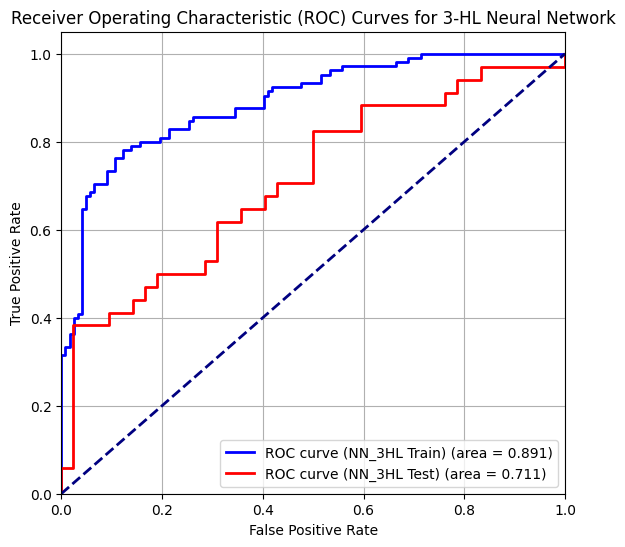

In [94]:
# Calculate ROC curve for training data (Neural Network with 3 Hidden Layers)
with torch.no_grad():
    y_prob_NN_3HL_train = model_NN_3HL(X_train_tensor)
    fpr_NN_3HL_train, tpr_NN_3HL_train, thr_NN_3HL_train = roc_curve(y_train_tensor.cpu().numpy(), y_prob_NN_3HL_train.cpu().numpy())
    roc_auc_NN_3HL_train = auc(fpr_NN_3HL_train, tpr_NN_3HL_train)

# Calculate ROC curve for test data (Neural Network with 3 Hidden Layers)
with torch.no_grad():
    y_prob_NN_3HL_test = model_NN_3HL(X_test_tensor)
    fpr_NN_3HL_test, tpr_NN_3HL_test, thr_NN_3HL_test = roc_curve(y_test_tensor.cpu().numpy(), y_prob_NN_3HL_test.cpu().numpy())
    roc_auc_NN_3HL_test = auc(fpr_NN_3HL_test, tpr_NN_3HL_test)

# Create a single plot to overlay both ROC curves for the Neural Network with 3 Hidden Layers
plt.figure(figsize=(6.5, 6))

plt.plot(fpr_NN_3HL_train, tpr_NN_3HL_train, color='blue', lw=2, label=f'ROC curve (NN_3HL Train) (area = {roc_auc_NN_3HL_train:.3f})')
plt.plot(fpr_NN_3HL_test, tpr_NN_3HL_test, color='red', lw=2, label=f'ROC curve (NN_3HL Test) (area = {roc_auc_NN_3HL_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for 3-HL Neural Network')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()